<a href="https://colab.research.google.com/github/AidaSadeghi/Finance-FinacialMarkets/blob/main/BusinessDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Net Present Value (NPV)**

Concept: The current value of all future cash flows (both positive and negative) across an investment's lifespan, adjusted (discounted) to today's value

In [1]:
def calculate_npv(rate, initial_investment, cash_flows):
    # Initial investment is usually a negative value (cash outflow)
    total_npv = initial_investment
    for t, cash_flow in enumerate(cash_flows, start=1):
        # Discount each cash flow back to year 0
        total_npv += cash_flow / (1 + rate)**t
    return total_npv

# Example: $1000 investment with $400 returns for 3 years at 10% discount rate
discount_rate = 0.10
investment = -1000
future_returns = [400, 400, 400]

npv_result = calculate_npv(discount_rate, investment, future_returns)
print(f"Project NPV: ${npv_result:.2f}")

Project NPV: $-5.26


**2. Weighted Average Cost of Capital (WACC)**

Concept: The average rate a company pays to finance its assets, calculated by weighting the cost of debt and equity by their respective proportions in the firm's capital structure.

In [2]:
def calculate_wacc(market_equity, total_debt, cost_of_equity, cost_of_debt):
    total_capital = market_equity + total_debt

    # Proportions (weights)
    weight_equity = market_equity / total_capital
    weight_debt = total_debt / total_capital

    # WACC Formula
    wacc = (weight_equity * cost_of_equity) + (weight_debt * cost_of_debt)
    return wacc

# Example based on presentation data
equity_val = 193  # $bn
debt_val = 32     # $bn
equity_cost = 0.09
debt_cost = 0.035

firm_wacc = calculate_wacc(equity_val, debt_val, equity_cost, debt_cost)
print(f"Firm WACC: {firm_wacc * 100:.2f}%")

Firm WACC: 8.22%


**3. Capital Return Decision Logic**

Concept: Managers must decide whether to reinvest cash or return it to investors. The rule is to return capital (via dividends or buybacks) if the expected internal return is lower than the company’s cost of capital (WACC).

In [3]:
def return_capital_decision(project_irr, company_wacc):
    # If Internal Rate of Return (IRR) is less than WACC, return cash to investors
    if project_irr < company_wacc:
        return "Action: Pay Dividends or Buyback Shares"
    else:
        return "Action: Reinvest in Internal Projects"

# Example: 22% expected return vs 28% WACC [cite: 64]
irr = 0.22
wacc = 0.28

decision = return_capital_decision(irr, wacc)
print(f"Strategic Decision: {decision}")

Strategic Decision: Action: Pay Dividends or Buyback Shares


**4. Terminal Value (Perpetual Growth)**


Concept: The value of all future cash flows beyond a specific forecast period, often calculated using the growing perpetuity formula.

In [4]:
def calculate_terminal_value(final_cash_flow, growth_rate, wacc):
    # TV = (Final Cash Flow * (1 + growth)) / (WACC - growth)
    numerator = final_cash_flow * (1 + growth_rate)
    denominator = wacc - growth_rate
    return numerator / denominator

# Example data from presentation [cite: 13]
fcf_last_year = 100
long_term_growth = 0.0154
cost_of_cap = 0.10

tv = calculate_terminal_value(fcf_last_year, long_term_growth, cost_of_cap)
print(f"Terminal Value: ${tv:.2f}")

Terminal Value: $1200.24


**1. The Accounting Equation**


Definition: The foundation of all accounting. It states that a company's assets must always be equal to the sum of its liabilities and shareholders' equity.

In [5]:
def check_accounting_balance(assets, liabilities, equity):
    # Assets = Liabilities + Equity
    is_balanced = assets == (liabilities + equity)

    if is_balanced:
        return "The books are balanced."
    else:
        difference = assets - (liabilities + equity)
        return f"Error: Books are out of balance by {difference}"

# Example: $500k in assets, $200k in debt, $300k in equity
print(check_accounting_balance(500000, 200000, 300000))

The books are balanced.


**2. Double-Entry Bookkeeping**


Definition: Every financial transaction affects at least two accounts. A "Debit" increases certain accounts (like Assets), while a "Credit" increases others (like Revenue or Liabilities).

In [6]:
class Ledger:
    def __init__(self):
        self.cash = 1000  # Asset
        self.revenue = 0  # Equity/Income

    def record_sale(self, amount):
        print(f"Recording sale of ${amount}...")
        # Double-entry: Increase Cash (Debit) and Increase Revenue (Credit)
        self.cash += amount
        self.revenue += amount
        print(f"Updated Cash: ${self.cash} | Total Revenue: ${self.revenue}")

my_business = Ledger()
my_business.record_sale(500)

Recording sale of $500...
Updated Cash: $1500 | Total Revenue: $500


**3. Straight-Line Depreciation**


Definition: Spreading the cost of a tangible asset over its useful life. This follows the Matching Principle, where the expense is recognized in the periods the asset helps generate revenue.

![image.png](
  
)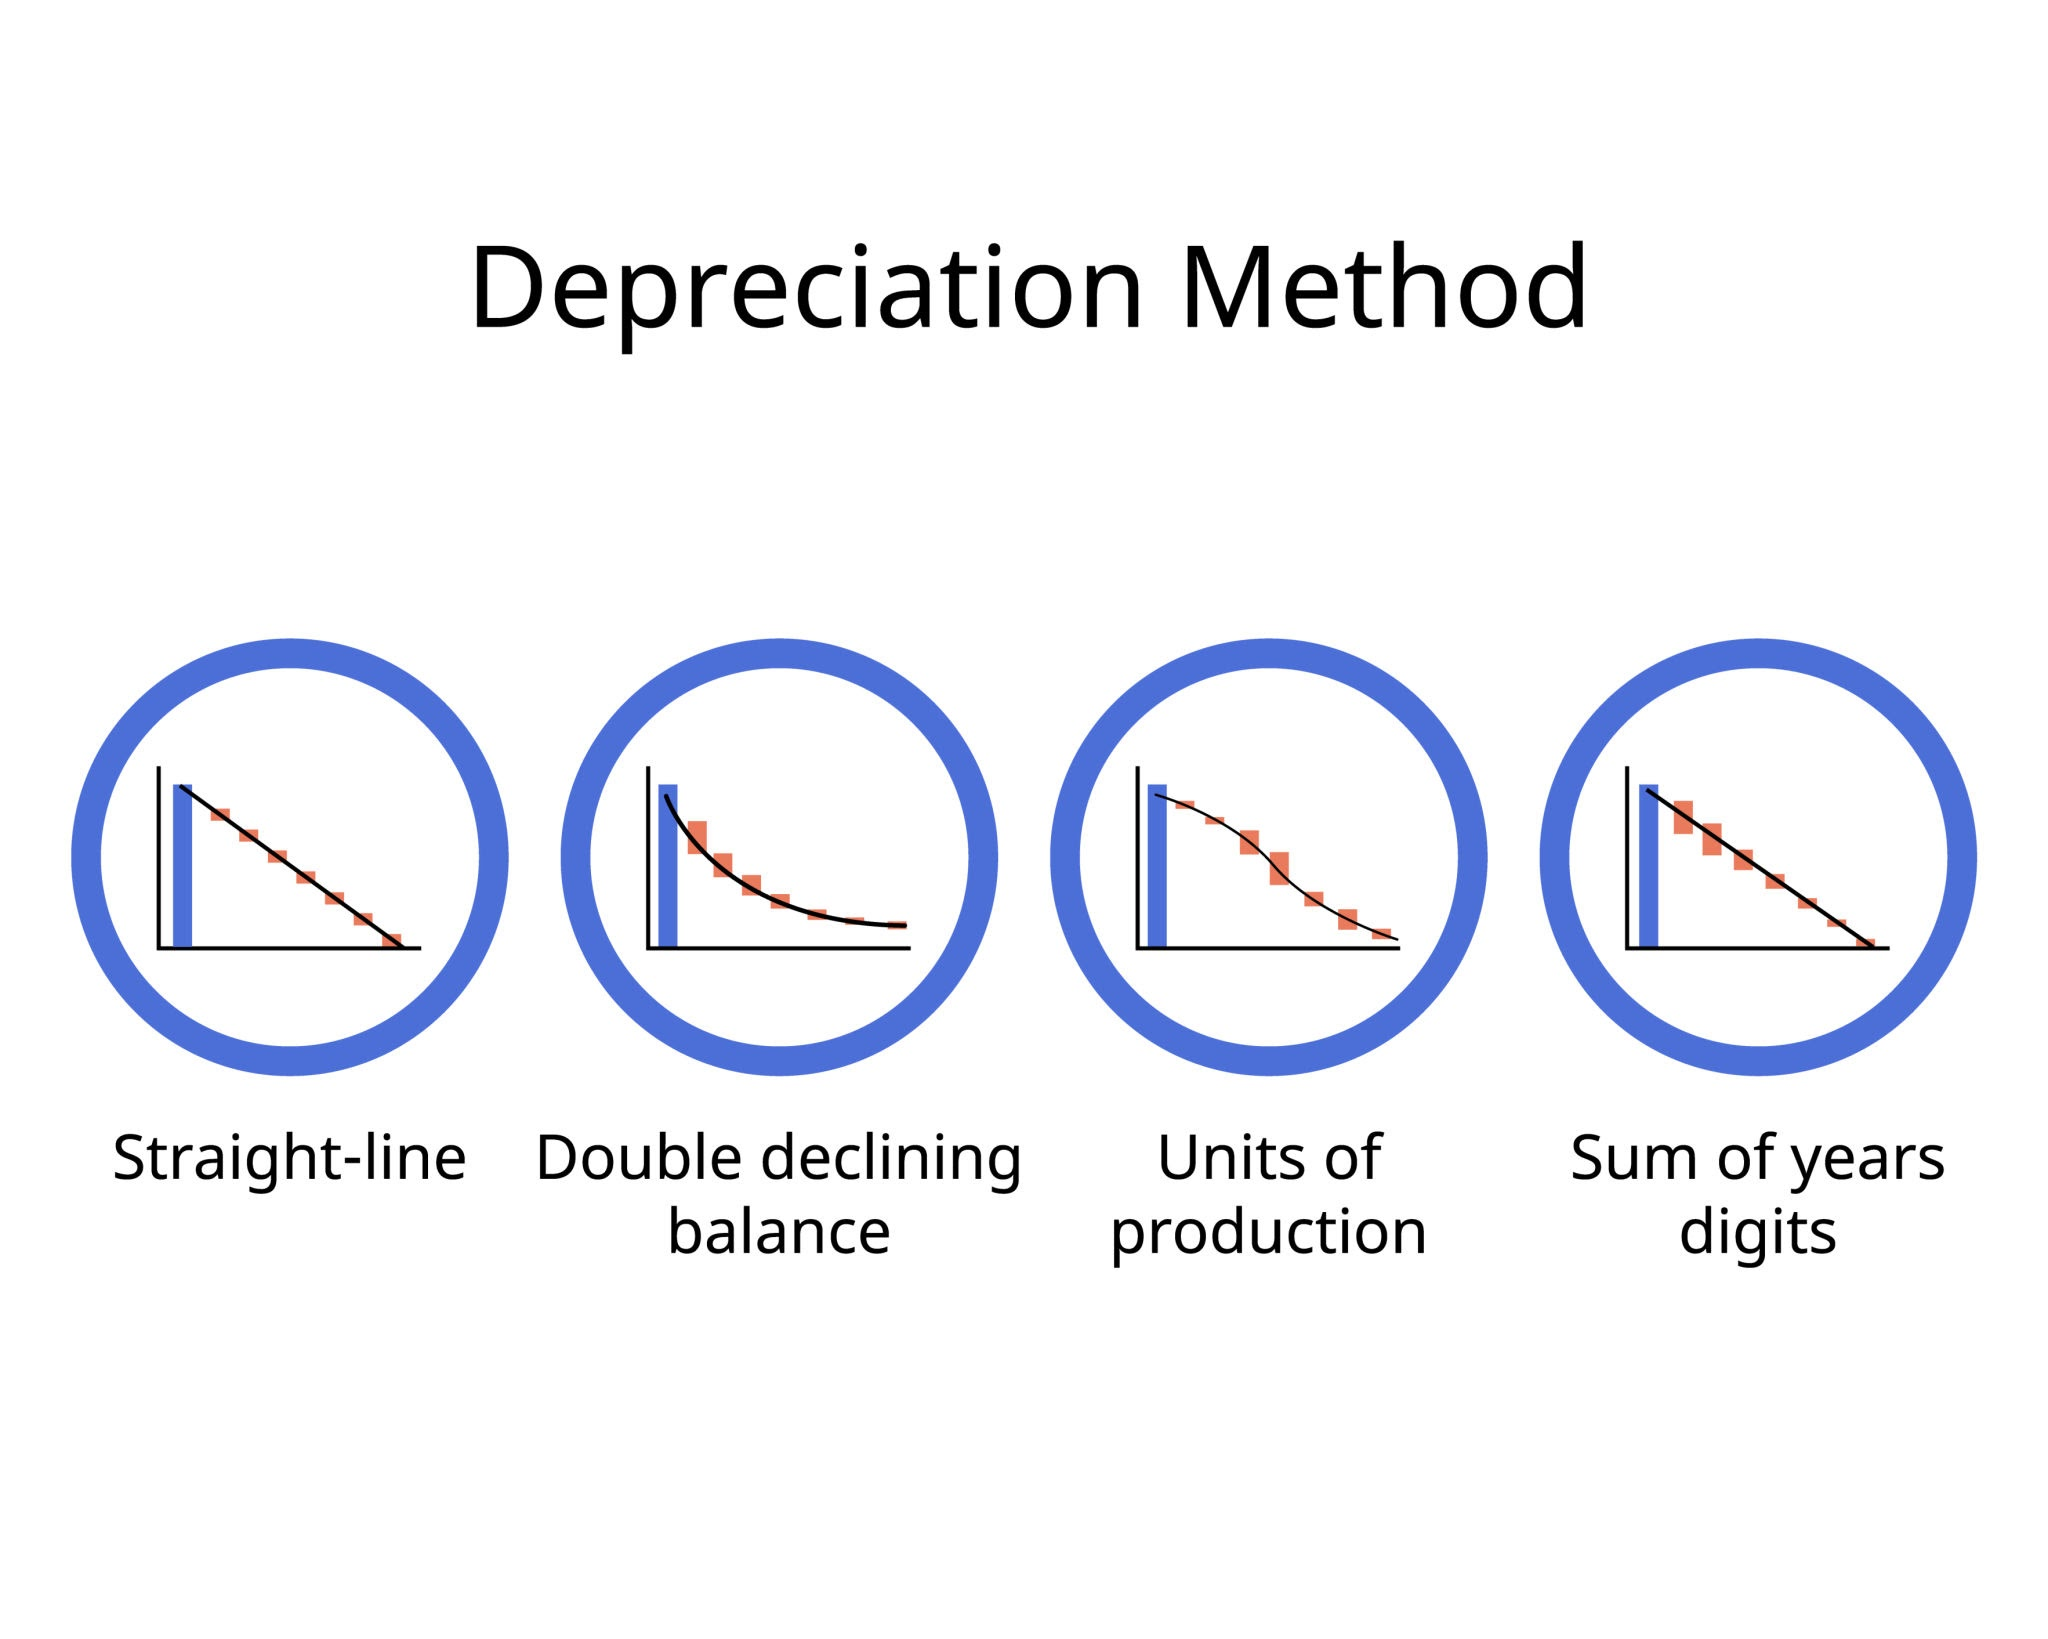

In [7]:
def calculate_annual_depreciation(purchase_price, salvage_value, useful_life_years):
    # (Cost - Salvage Value) / Useful Life
    depreciable_base = purchase_price - salvage_value
    annual_expense = depreciable_base / useful_life_years
    return annual_expense

# Example: A $45,500 car, worth $10,000 in 5 years
car_expense = calculate_annual_depreciation(45500, 10000, 5)
print(f"Annual Depreciation Expense: ${car_expense:.2f}")

Annual Depreciation Expense: $7100.00


**4. Accrual Accounting (The Matching Principle)**


Definition: Recording revenue when it is earned and expenses when they are incurred, regardless of when the cash actually moves.

In [8]:
class AccrualAccounting:
    def __init__(self):
        self.accounts_receivable = 0
        self.earned_revenue = 0

    def deliver_service(self, service_value):
        # Service delivered but customer hasn't paid cash yet
        self.earned_revenue += service_value
        self.accounts_receivable += service_value
        print(f"Revenue Recognized: ${self.earned_revenue}")
        print(f"Amount Customer Still Owes: ${self.accounts_receivable}")

# Even though cash is $0, the company reports profit
firm = AccrualAccounting()
firm.deliver_service(2500)

Revenue Recognized: $2500
Amount Customer Still Owes: $2500


**5. Gross Profit Margin**


Definition: A profitability ratio that shows the percentage of revenue exceeding the Cost of Goods Sold (COGS).

In [9]:
def calculate_gross_margin(revenue, cogs):
    gross_profit = revenue - cogs
    margin_percentage = (gross_profit / revenue) * 100
    return margin_percentage

# Example: $1M in sales, $600k in product costs
margin = calculate_gross_margin(1000000, 600000)
print(f"Gross Profit Margin: {margin}%")

Gross Profit Margin: 40.0%
